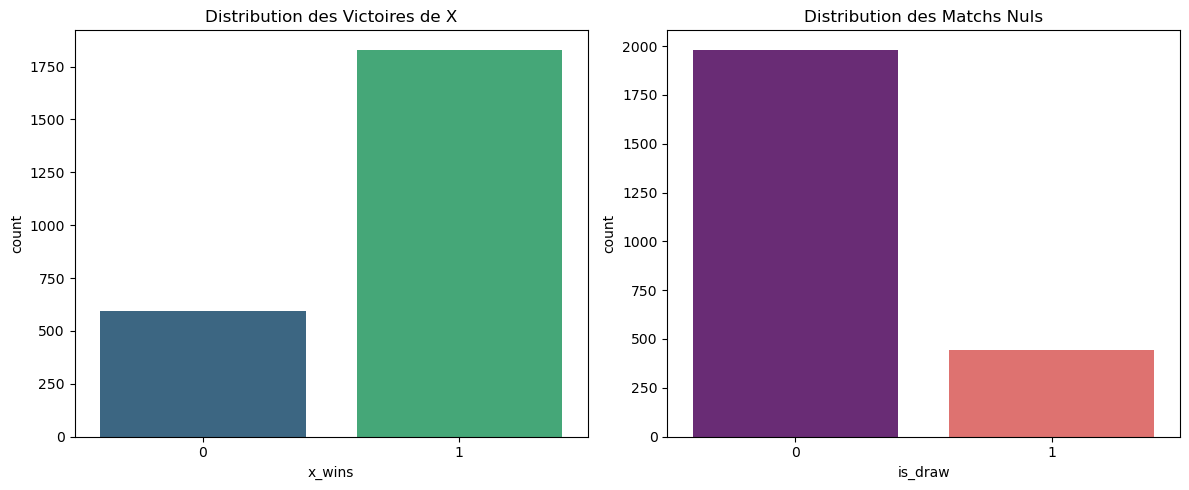


--- Logistic — x_wins ---
              precision    recall  f1-score   support

           0       0.31      0.54      0.39       119
           1       0.80      0.60      0.69       366

    accuracy                           0.59       485
   macro avg       0.55      0.57      0.54       485
weighted avg       0.68      0.59      0.62       485


--- Logistic — is_draw ---
              precision    recall  f1-score   support

           0       0.83      0.60      0.70       397
           1       0.19      0.43      0.27        88

    accuracy                           0.57       485
   macro avg       0.51      0.52      0.48       485
weighted avg       0.71      0.57      0.62       485


--- Random Forest — x_wins ---
              precision    recall  f1-score   support

           0       0.97      0.50      0.66       119
           1       0.86      0.99      0.92       366

    accuracy                           0.87       485
   macro avg       0.91      0.75      0.

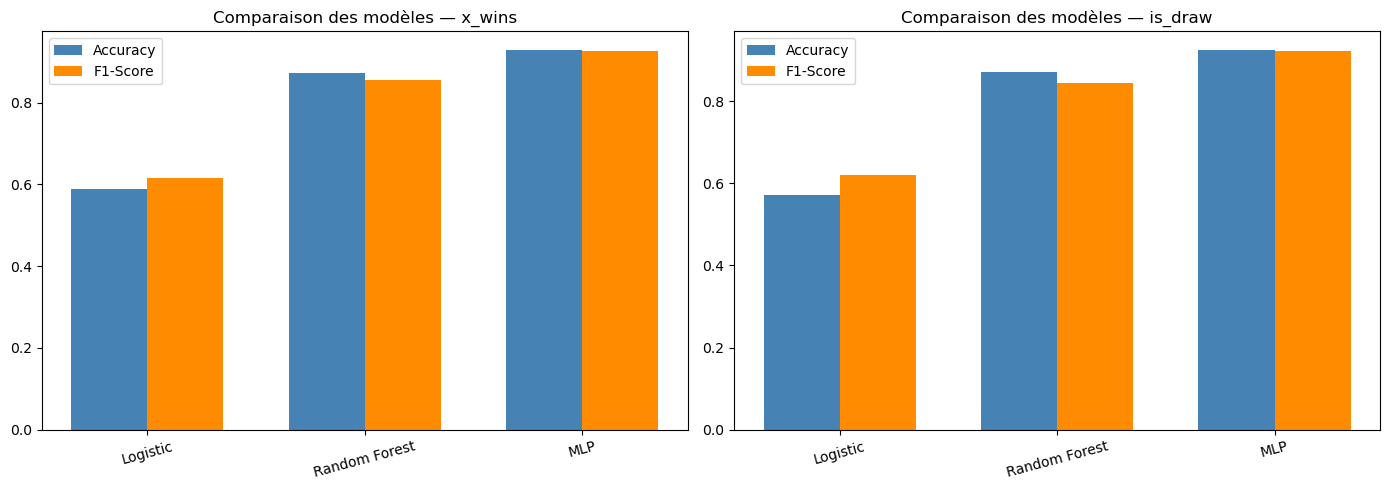

✅ Terminé. Modèles sauvegardés dans /models (XGBoost retiré).


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# =================================================================
# 1. PRÉPARATION DE L'ENVIRONNEMENT ET DES DONNÉES
# =================================================================

# Création des dossiers pour les livrables
os.makedirs('models', exist_ok=True)
os.makedirs('ressources', exist_ok=True)

# Chargement du dataset généré par Sariaka
df = pd.read_csv('dataset.csv')

# Définition des caractéristiques (X) et des cibles (y)
X = df.drop(['x_wins', 'is_draw'], axis=1)
y_wins = df['x_wins']
y_draw = df['is_draw']

# Découpage du dataset (80% entraînement, 20% test)
# Stratify assure une répartition équilibrée des classes (Victoires/Nuls)
X_train, X_test, yw_train, yw_test = train_test_split(
    X, y_wins, test_size=0.2, random_state=42, stratify=y_wins
)

# Split spécifique pour la cible 'is_draw'
X_train_d, X_test_d, yd_train, yd_test = train_test_split(
    X, y_draw, test_size=0.2, random_state=42, stratify=y_draw
)

# =================================================================
# 2. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# =================================================================

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='x_wins', data=df, hue='x_wins', palette='viridis', legend=False)
plt.title('Distribution des Victoires de X')

plt.subplot(1, 2, 2)
sns.countplot(x='is_draw', data=df, hue='is_draw', palette='magma', legend=False)
plt.title('Distribution des Matchs Nuls')
plt.tight_layout()
plt.show()

# =================================================================
# 3. ÉVALUATION ET ENTRAÎNEMENT DES MODÈLES
# =================================================================

results = {}

def evaluate(name, y_true, y_pred):
    """Calcule et stocke les métriques de performance"""
    report = classification_report(y_true, y_pred, output_dict=True)
    acc = accuracy_score(y_true, y_pred)
    f1 = report['weighted avg']['f1-score']
    
    print(f"\n--- {name} ---")
    print(classification_report(y_true, y_pred))
    
    return {'model': name, 'accuracy': acc, 'f1': f1}

# --- BASELINE : RÉGRESSION LOGISTIQUE ---
lr_wins = LogisticRegression(class_weight='balanced', random_state=42)
lr_wins.fit(X_train, yw_train)
results['LR_xwins'] = evaluate("Logistic — x_wins", yw_test, lr_wins.predict(X_test))

lr_draw = LogisticRegression(class_weight='balanced', random_state=42)
lr_draw.fit(X_train_d, yd_train)
results['LR_draw'] = evaluate("Logistic — is_draw", yd_test, lr_draw.predict(X_test_d))

# --- MODÈLES AVANCÉS ---
# Random Forest (Forêt Aléatoire)
rf_wins = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_wins.fit(X_train, yw_train)
results['RF_xwins'] = evaluate("Random Forest — x_wins", yw_test, rf_wins.predict(X_test))

rf_draw = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_draw.fit(X_train_d, yd_train)
results['RF_draw'] = evaluate("Random Forest — is_draw", yd_test, rf_draw.predict(X_test_d))

# MLP (Réseau de Neurones Multi-couches)
mlp_wins = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_wins.fit(X_train, yw_train)
results['MLP_xwins'] = evaluate("MLP — x_wins", yw_test, mlp_wins.predict(X_test))

mlp_draw = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_draw.fit(X_train_d, yd_train)
results['MLP_draw'] = evaluate("MLP — is_draw", yd_test, mlp_draw.predict(X_test_d))

# =================================================================
# 4. COMPARAISON ET SAUVEGARDE FINALE
# =================================================================

# Préparation des données pour le graphique comparatif
rows = []
for key, r in results.items():
    target = 'x_wins' if 'xwins' in key else 'is_draw'
    model_name = r['model'].split('—')[0].strip()
    rows.append({'Modèle': model_name, 'Cible': target, 'Accuracy': r['accuracy'], 'F1-Score': r['f1']})

df_results = pd.DataFrame(rows)

# Visualisation des performances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, ['x_wins', 'is_draw']):
    sub = df_results[df_results['Cible'] == target]
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width/2, sub['Accuracy'], width, label='Accuracy', color='steelblue')
    ax.bar(x + width/2, sub['F1-Score'], width, label='F1-Score', color='darkorange')
    ax.set_title(f"Comparaison des modèles — {target}")
    ax.set_xticks(x)
    ax.set_xticklabels(sub['Modèle'], rotation=15)
    ax.legend()

plt.tight_layout()
plt.show()

# Sauvegarde des modèles au format .joblib
joblib.dump(lr_wins, 'models/lr_xwins.joblib')
joblib.dump(lr_draw, 'models/lr_draw.joblib')
joblib.dump(rf_wins, 'models/rf_xwins.joblib')
joblib.dump(rf_draw, 'models/rf_draw.joblib')
joblib.dump(mlp_wins, 'models/mlp_xwins.joblib')
joblib.dump(mlp_draw, 'models/mlp_draw.joblib')

print(f"✅ Terminé. Modèles sauvegardés dans /models.")

In [15]:
#Adaptation pour l'utilisation avec JS
import json
import numpy as np

# 1. Extraction des données de la Régression Logistique (Baseline)
baseline_data = {
    "coefficients": lr_wins.coef_[0].tolist(),
    "intercept": float(lr_wins.intercept_[0])
}

# 2. Extraction des données du Random Forest (Modèle Avancé)
# Nous allons exporter l'importance des caractéristiques pour chaque case
# Cela permet à l'IA en JS de savoir quelles cases le RF juge prioritaires
rf_importance = rf_wins.feature_importances_.tolist()

model_export = {
    "baseline": baseline_data,
    "advanced": {
        "feature_importance": rf_importance,
        "description": "Random Forest Weights"
    }
}

# Sauvegarde finale
with open('ressources/model_data.json', 'w') as f:
    json.dump(model_export, f, indent=4)

print(" Fichier model_data.json généré avec les DEUX modèles !")

✅ Fichier model_data.json généré avec les DEUX modèles !


In [16]:
import json

# 1. On prépare la structure avec tes données actuelles (Baseline)
# On regroupe tes deux dictionnaires x_wins et is_draw sous la clé "baseline"
baseline_content = {
    "x_wins": {
        "coefficients": [0.09498130164575755, -0.09988397778240332, -0.35868873966044185, 0.26298471774455123, 0.10078090814195922, -0.23701478760036834, -0.3449655084862486, 0.20726734490857637, 0.038007216603949075, -0.9813474856580717, -0.4472451267638162, 0.14126620821817726, 0.16536085960318395, -0.1654538566878094, -0.38888641342322006, 0.10572457923905339, 0.20379073185835528, -0.17040751286222786],
        "intercept": 0.6599361783112832
    },
    "is_draw": {
        "coefficients": [-0.10899704886147771, -0.037900153115440864, 0.2635121148969123, -0.0972954582360018, -0.06507732042165086, 0.1034500600073031, 0.19759712822084666, -0.17102368026481332, 0.22702303039274824, 0.8857309845347271, 0.30178259119326145, 0.007473247966989643, -0.12254757021824071, -0.005038513651895303, 0.25800213340463946, -0.0004758926736085469, -0.19082690439907035, 0.07554755964070656],
        "intercept": -0.5153000970079561
    }
}

# 2. On récupère les poids du Random Forest (Expert)
# rf_wins doit être ton modèle entraîné par Nathalie/Tsiory
rf_importance = rf_wins.feature_importances_.tolist()

# 3. On fusionne tout dans l'objet final
final_model_data = {
    "baseline": baseline_content,
    "expert": {
        "weights": rf_importance
    }
}

# 4. Sauvegarde physique
with open('ressources/model_data.json', 'w') as f:
    json.dump(final_model_data, f, indent=4)

print("✅ Fichier mis à jour avec les deux modes !")

✅ Fichier mis à jour avec les deux modes !
